In [8]:
from pathlib import Path
import pandas as pd

data_path = Path("/Users/adhamelbaz/2026-orion/data/egx/SAUD.csv")

print("File exists:", data_path.exists())
print("Resolved path:", data_path.resolve())

File exists: True
Resolved path: /Users/adhamelbaz/2026-orion/data/egx/SAUD.csv


In [9]:
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Shape: (2859, 6)
Columns: ['date', 'open', 'high', 'low', 'close', 'volume']


,date,open,high,low,close,volume
0,2015-01-04,2.03802,2.127700,2.110116,2.03802,2843
1,2015-01-05,2.03802,2.038020,1.997577,2.03802,3412
2,2015-01-06,2.03802,2.022195,2.022195,2.03802,2843
3,2015-01-08,2.03802,2.023953,2.023953,2.03802,2843
4,2015-01-11,2.03802,2.038020,2.038020,2.03802,0


In [10]:
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

display(df.head())

Columns: ['date', 'open', 'high', 'low', 'close', 'volume']

Data types:
date          str
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object


,date,open,high,low,close,volume
0,2015-01-04,2.03802,2.127700,2.110116,2.03802,2843
1,2015-01-05,2.03802,2.038020,1.997577,2.03802,3412
2,2015-01-06,2.03802,2.022195,2.022195,2.03802,2843
3,2015-01-08,2.03802,2.023953,2.023953,2.03802,2843
4,2015-01-11,2.03802,2.038020,2.038020,2.03802,0


In [11]:
import pandas as pd

date_column = "date"
price_column = "close"

data = df[[date_column, price_column]].copy()
data.columns = ["Date", "Price"]

data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data["Price"] = pd.to_numeric(data["Price"], errors="coerce")

data = (
    data.dropna()
        .drop_duplicates(subset="Date")
        .sort_values("Date")
        .reset_index(drop=True)
)

print("Price column used:", price_column)
print("Rows:", len(data))
print("Period:", data["Date"].min(), "to", data["Date"].max())

display(data.head())

Price column used: close
Rows: 2859
Period: 2015-01-04 00:00:00 to 2026-07-30 00:00:00


,Date,Price
0,2015-01-04,2.03802
1,2015-01-05,2.03802
2,2015-01-06,2.03802
3,2015-01-08,2.03802
4,2015-01-11,2.03802


In [12]:
data["MA9"] = data["Price"].rolling(window=9).mean()
data["MA20"] = data["Price"].rolling(window=20).mean()

display(data[["Date", "Price", "MA9", "MA20"]].tail(10))

,Date,Price,MA9,MA20
2849,2026-07-16,21.690001,21.562222,21.3615
2850,2026-07-19,21.590000,21.565556,21.3430
2851,2026-07-20,21.590000,21.552222,21.3350
2852,2026-07-21,21.950001,21.640000,21.3450
2853,2026-07-22,22.110001,21.681111,21.3715
2854,2026-07-26,22.590000,21.783334,21.4495
2855,2026-07-27,22.580000,21.898889,21.5235
2856,2026-07-28,22.219999,21.970000,21.6320
2857,2026-07-29,22.290001,22.067778,21.7250
2858,2026-07-30,21.969999,22.098889,21.7700


In [13]:
display(data[["Date", "Price", "MA9", "MA20"]].head(25))

,Date,Price,MA9,MA20
0,2015-01-04,2.038020,NaN,NaN
1,2015-01-05,2.038020,NaN,NaN
2,2015-01-06,2.038020,NaN,NaN
3,2015-01-08,2.038020,NaN,NaN
4,2015-01-11,2.038020,NaN,NaN
5,2015-01-12,2.020436,NaN,NaN
6,2015-01-13,2.025711,NaN,NaN
7,2015-01-14,2.034504,NaN,NaN
8,2015-01-15,2.022195,2.032550,NaN
9,2015-01-18,2.022195,2.030791,NaN


In [15]:
data["Previous_MA9"] = data["MA9"].shift(1)
data["Previous_MA20"] = data["MA20"].shift(1)

buy_condition = (
    (data["MA9"] > data["MA20"]) &
    (data["Previous_MA9"] <= data["Previous_MA20"])
)

sell_condition = (
    (data["MA9"] < data["MA20"]) &
    (data["Previous_MA9"] >= data["Previous_MA20"])
)

data["Signal"] = 0
data.loc[buy_condition, "Signal"] = 1
data.loc[sell_condition, "Signal"] = -1

signals = data.loc[
    data["Signal"] != 0,
    ["Date", "Price", "MA9", "MA20", "Signal"]
].copy()

signals["Operation"] = signals["Signal"].map({
    1: "BUY",
    -1: "SELL"
})

display(signals)
print("Buy signals:", (data["Signal"] == 1).sum())
print("Sell signals:", (data["Signal"] == -1).sum())

,Date,Price,MA9,MA20,Signal,Operation
22,2015-02-05,2.108358,2.036262,2.030723,1,BUY
36,2015-02-25,2.023953,2.052674,2.061232,-1,SELL
78,2015-04-28,1.934273,1.914539,1.900159,1,BUY
96,2015-05-24,2.009886,1.968269,1.969793,-1,SELL
116,2015-06-21,1.934273,1.954397,1.949835,1,BUY
...,...,...,...,...,...,...
2724,2026-01-12,15.650000,15.364445,15.363500,1,BUY
2764,2026-03-10,18.110001,18.307778,18.375500,-1,SELL
2773,2026-03-25,19.250000,18.558889,18.494500,1,BUY
2812,2026-05-24,22.500000,22.862222,23.036500,-1,SELL


Buy signals: 81
Sell signals: 80


In [16]:
import numpy as np
import pandas as pd

initial_cash = 1000.0

cash = initial_cash
shares = 0.0
pending_signal = 0
trades = []
daily_values = []

for i, row in data.iterrows():
    date = row["Date"]
    price = row["Price"]

    # Execute yesterday's signal using today's closing price
    if pending_signal == 1 and shares == 0 and cash > 0:
        shares = cash / price
        invested_cash = cash
        cash = 0.0

        trades.append({
            "Operation": "BUY",
            "Execution_Date": date,
            "Execution_Price": price,
            "Shares": shares,
            "Amount_EGP": invested_cash
        })

    elif pending_signal == -1 and shares > 0:
        sale_value = shares * price

        trades.append({
            "Operation": "SELL",
            "Execution_Date": date,
            "Execution_Price": price,
            "Shares": shares,
            "Amount_EGP": sale_value
        })

        cash = sale_value
        shares = 0.0

    # Calculate portfolio value after any execution
    portfolio_value = cash + (shares * price)

    daily_values.append({
        "Date": date,
        "Price": price,
        "Cash": cash,
        "Shares": shares,
        "Portfolio_Value": portfolio_value
    })

    # Today's signal becomes pending for tomorrow
    pending_signal = row["Signal"]

portfolio = pd.DataFrame(daily_values)
trades_df = pd.DataFrame(trades)

display(trades_df)
display(portfolio.tail())

,Operation,Execution_Date,Execution_Price,Shares,Amount_EGP
0,BUY,2015-02-08,2.085498,479.501757,1000.000000
1,SELL,2015-02-26,1.978234,479.501757,948.566703
2,BUY,2015-04-29,1.928998,491.740638,948.566703
3,SELL,2015-05-25,2.009886,491.740638,988.342636
4,BUY,2015-06-22,1.934273,510.963361,988.342636
...,...,...,...,...,...
156,BUY,2026-01-13,15.850000,139.426766,2209.914298
157,SELL,2026-03-11,18.000000,139.426766,2509.681792
158,BUY,2026-03-26,19.790001,126.815648,2509.681792
159,SELL,2026-05-25,22.950001,126.815648,2910.419221


,Date,Price,Cash,Shares,Portfolio_Value
2854,2026-07-26,22.590000,0.0,134.866507,3046.634424
2855,2026-07-27,22.580000,0.0,134.866507,3045.285728
2856,2026-07-28,22.219999,0.0,134.866507,2996.733703
2857,2026-07-29,22.290001,0.0,134.866507,3006.174575
2858,2026-07-30,21.969999,0.0,134.866507,2963.017076


In [17]:
portfolio["Running_Peak"] = portfolio["Portfolio_Value"].cummax()

portfolio["Drawdown_EGP"] = (
    portfolio["Portfolio_Value"] - portfolio["Running_Peak"]
)

portfolio["Drawdown_Percent"] = (
    portfolio["Drawdown_EGP"] / portfolio["Running_Peak"] * 100
)

final_portfolio_value = portfolio["Portfolio_Value"].iloc[-1]
max_drawdown_egp = abs(portfolio["Drawdown_EGP"].min())
max_drawdown_percent = abs(portfolio["Drawdown_Percent"].min())

buy_count = (
    (trades_df["Operation"] == "BUY").sum()
    if not trades_df.empty else 0
)

sell_count = (
    (trades_df["Operation"] == "SELL").sum()
    if not trades_df.empty else 0
)

total_return = (
    (final_portfolio_value / initial_cash) - 1
) * 100

print(f"Initial portfolio:     {initial_cash:,.2f} EGP")
print(f"Final portfolio value: {final_portfolio_value:,.2f} EGP")
print(f"Total return:          {total_return:,.2f}%")
print(f"Maximum drawdown:      {max_drawdown_egp:,.2f} EGP")
print(f"Maximum drawdown:      {max_drawdown_percent:,.2f}%")
print(f"Buy operations:        {buy_count}")
print(f"Sell operations:       {sell_count}")
print(f"Total operations:      {buy_count + sell_count}")

Initial portfolio:     1,000.00 EGP
Final portfolio value: 2,963.02 EGP
Total return:          196.30%
Maximum drawdown:      926.06 EGP
Maximum drawdown:      37.98%
Buy operations:        81
Sell operations:       80
Total operations:      161


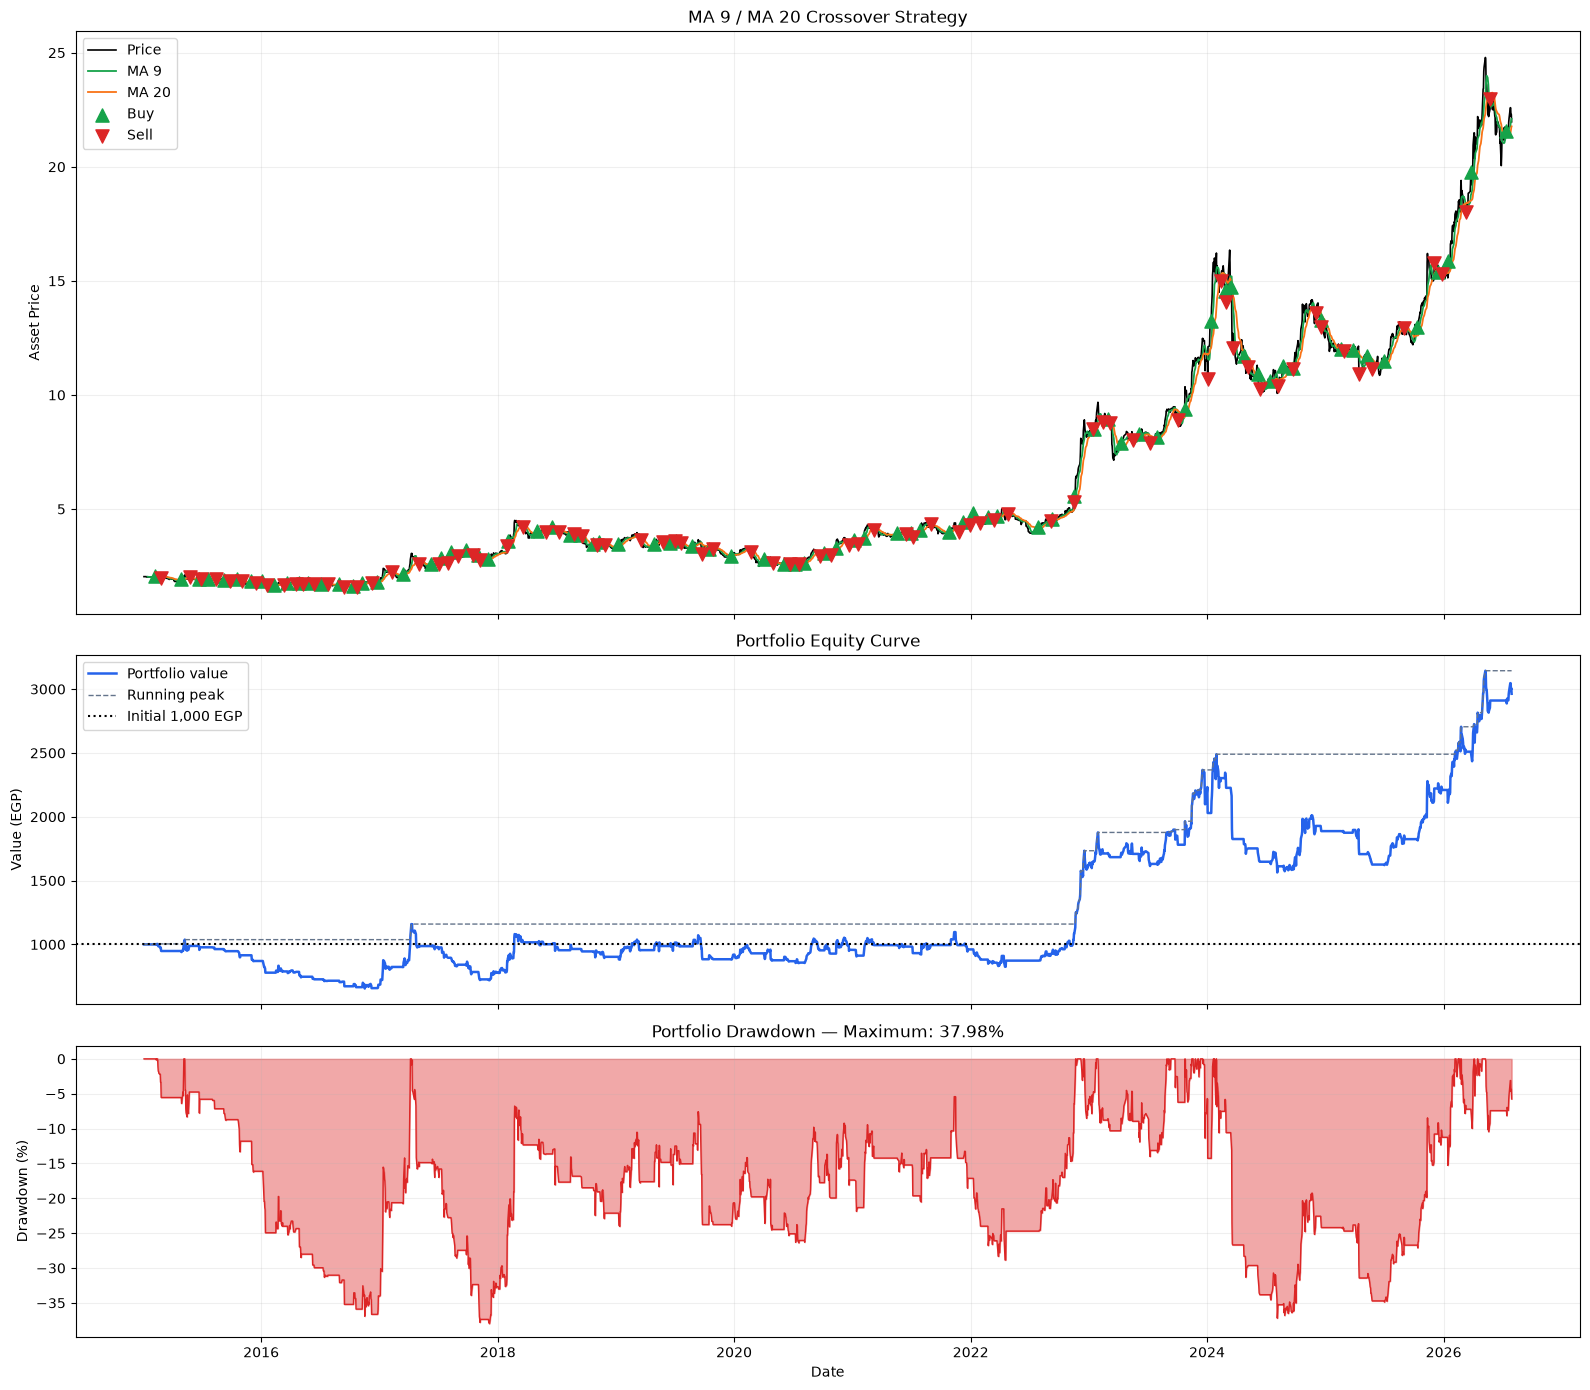

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

buy_trades = trades_df[trades_df["Operation"] == "BUY"]
sell_trades = trades_df[trades_df["Operation"] == "SELL"]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 14),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1.2, 1]}
)

# 1. Price, moving averages and operations
axes[0].plot(
    data["Date"], data["Price"],
    label="Price", color="black", linewidth=1.2
)
axes[0].plot(
    data["Date"], data["MA9"],
    label="MA 9", color="#16a34a", linewidth=1.3
)
axes[0].plot(
    data["Date"], data["MA20"],
    label="MA 20", color="#f97316", linewidth=1.3
)

if not buy_trades.empty:
    axes[0].scatter(
        buy_trades["Execution_Date"],
        buy_trades["Execution_Price"],
        marker="^",
        color="#16a34a",
        s=90,
        label="Buy",
        zorder=5
    )

if not sell_trades.empty:
    axes[0].scatter(
        sell_trades["Execution_Date"],
        sell_trades["Execution_Price"],
        marker="v",
        color="#dc2626",
        s=90,
        label="Sell",
        zorder=5
    )

axes[0].set_title("MA 9 / MA 20 Crossover Strategy")
axes[0].set_ylabel("Asset Price")
axes[0].legend()
axes[0].grid(alpha=0.2)

# 2. Portfolio equity curve
axes[1].plot(
    portfolio["Date"],
    portfolio["Portfolio_Value"],
    color="#2563eb",
    linewidth=1.8,
    label="Portfolio value"
)
axes[1].plot(
    portfolio["Date"],
    portfolio["Running_Peak"],
    color="#64748b",
    linestyle="--",
    linewidth=1,
    label="Running peak"
)

axes[1].axhline(
    initial_cash,
    color="black",
    linestyle=":",
    label="Initial 1,000 EGP"
)

axes[1].set_title("Portfolio Equity Curve")
axes[1].set_ylabel("Value (EGP)")
axes[1].legend()
axes[1].grid(alpha=0.2)

# 3. Drawdown
axes[2].fill_between(
    portfolio["Date"],
    portfolio["Drawdown_Percent"],
    0,
    color="#dc2626",
    alpha=0.4
)
axes[2].plot(
    portfolio["Date"],
    portfolio["Drawdown_Percent"],
    color="#dc2626",
    linewidth=1
)

axes[2].set_title(
    f"Portfolio Drawdown — Maximum: {max_drawdown_percent:.2f}%"
)
axes[2].set_ylabel("Drawdown (%)")
axes[2].set_xlabel("Date")
axes[2].grid(alpha=0.2)

axes[2].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[2].xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(axes[2].xaxis.get_major_locator())
)

plt.tight_layout()
plt.show()